In [4]:
# Import necessary libraries
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

In [5]:
# Download NLTK data
nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\vishn\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\vishn\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [6]:
# Load the 20 Newsgroups dataset
newsgroups = fetch_20newsgroups(subset='all', remove=('headers', 'footers', 'quotes'))
print(f"Number of documents: {len(newsgroups.data)}")
print(f"Number of categories: {len(newsgroups.target_names)}")
print("Categories:", newsgroups.target_names)

Number of documents: 18846
Number of categories: 20
Categories: ['alt.atheism', 'comp.graphics', 'comp.os.ms-windows.misc', 'comp.sys.ibm.pc.hardware', 'comp.sys.mac.hardware', 'comp.windows.x', 'misc.forsale', 'rec.autos', 'rec.motorcycles', 'rec.sport.baseball', 'rec.sport.hockey', 'sci.crypt', 'sci.electronics', 'sci.med', 'sci.space', 'soc.religion.christian', 'talk.politics.guns', 'talk.politics.mideast', 'talk.politics.misc', 'talk.religion.misc']


In [7]:
# Define preprocessing function using NLTK
def preprocess_text(text):
    # Tokenize
    tokens = nltk.word_tokenize(text)
    # Convert to lowercase and keep only alphabetic words
    tokens = [word.lower() for word in tokens if word.isalpha()]
    # Remove stop words
    stop_words = set(stopwords.words('english'))
    tokens = [word for word in tokens if word not in stop_words]
    # Stemming
    stemmer = PorterStemmer()
    tokens = [stemmer.stem(word) for word in tokens]
    # Join back to string
    return ' '.join(tokens)

In [8]:
# Preprocess the data
X = [preprocess_text(text) for text in newsgroups.data]
y = newsgroups.target

In [9]:
# Vectorize the text using TF-IDF
vectorizer = TfidfVectorizer(max_features=5000)
X_vec = vectorizer.fit_transform(X)

In [10]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_vec, y, test_size=0.2, random_state=42)

In [11]:
# Train the Naive Bayes model
model = MultinomialNB()
model.fit(X_train, y_train)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [12]:
# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=newsgroups.target_names))

Accuracy: 0.6925729442970823

Classification Report:
                          precision    recall  f1-score   support

             alt.atheism       0.61      0.41      0.49       151
           comp.graphics       0.59      0.65      0.62       202
 comp.os.ms-windows.misc       0.62      0.64      0.63       195
comp.sys.ibm.pc.hardware       0.51      0.70      0.59       183
   comp.sys.mac.hardware       0.83      0.60      0.70       205
          comp.windows.x       0.76      0.77      0.77       215
            misc.forsale       0.80      0.67      0.73       193
               rec.autos       0.76      0.69      0.73       196
         rec.motorcycles       0.44      0.76      0.56       168
      rec.sport.baseball       0.88      0.80      0.84       211
        rec.sport.hockey       0.87      0.90      0.89       198
               sci.crypt       0.74      0.78      0.76       201
         sci.electronics       0.74      0.65      0.69       202
                 sci.m

<Axes: >

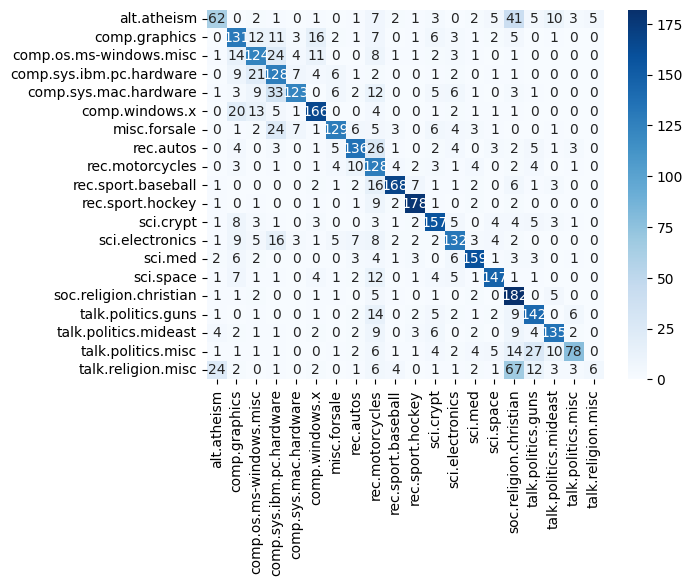

In [ ]:
# Visualize the results (optional)
import seaborn as sns

# Create a confusion matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=newsgroups.target_names, yticklabels=newsgroups.target_names)
